## 1. Import DS UTK Face from kaggle

In [4]:
import kagglehub
import shutil
from pathlib import Path

dataset = "jangedoo/utkface-new"

cache_path = kagglehub.dataset_download(dataset)

project_data = Path("../data/raw/")
project_data.mkdir(parents=True, exist_ok=True)

shutil.copytree(cache_path, project_data, dirs_exist_ok=True)

print("Copied dataset to:", project_data)


Copied dataset to: ..\data\raw


## 2. Create a dataframe 

### 2.1 Create a dataframe with metadata (age, gender, race) and image paths for easier data handling

In [ ]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw/utkface_aligned_cropped/utkface")  

records = []

for img_path in data_path.glob("*.jpg"):
    try:
        age, gender, race, _ = img_path.name.split("_", 3)
        
        records.append({
            "image_path": str(img_path),
            "age": int(age),
            "gender": int(gender),
            "race": int(race)
        })
        
    except:
        continue

df = pd.DataFrame(records)

df.head()



### 2.2 add age groups for better analysis and model training

In [ ]:
def age_group(age):
    if age < 30:
        return "young"
    elif age < 55:
        return "middle"
    else:
        return "old"

df["age_group"] = df["age"].apply(age_group)

df.head()

In [ ]:
#save it for later use
df.to_csv("../data/metadata/utkface_metadata.csv", index=False)

## 3. Data Exploration


### 3.1 Age distribution in the dataset

Skipping adjusting alignment as UTK face dataset has has a set of images with already aligned and cropped faces.

Number of samples: 23708


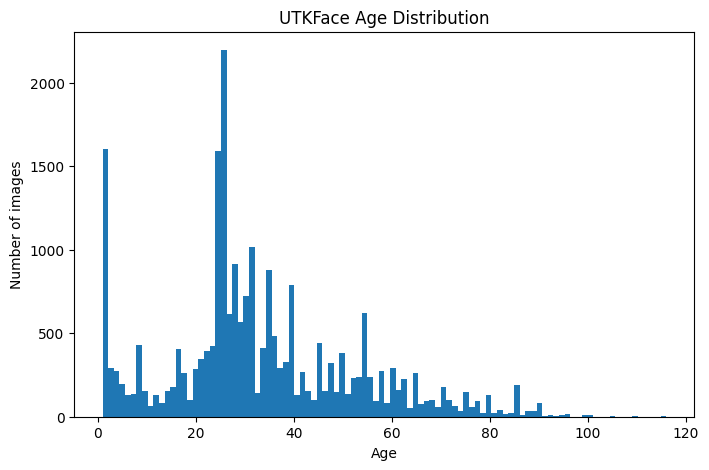

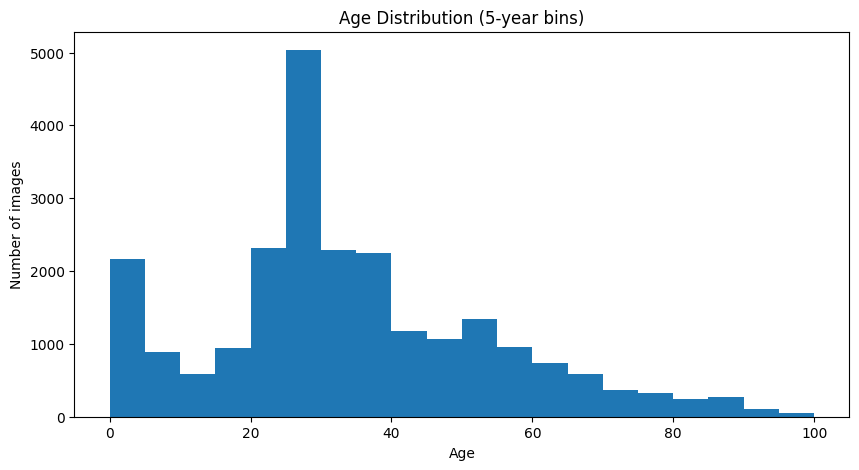

In [35]:
#distribution of age in the dataset 
import matplotlib.pyplot as plt

ages = []

for img in data_path.glob("*.jpg"):
    age = int(img.name.split("_")[0])
    ages.append(age)

print("Number of samples:", len(ages))

plt.figure(figsize=(8,5))
plt.hist(ages, bins=100)
plt.xlabel("Age")
plt.ylabel("Number of images")
plt.title("UTKFace Age Distribution")
plt.show()


plt.figure(figsize=(10,5))
plt.hist(ages, bins=range(0, 101, 5))
plt.xlabel("Age")
plt.ylabel("Number of images")
plt.title("Age Distribution (5-year bins)")
plt.show()

For our purpose we can drop the ages 0-10 as we want to focus on the adult population.
Leter we'll need to adjust the ds for ML as the distribution of ages is not uniform and we want to have a more balanced dataset for training our model.We can use techniques such as: </br>
-> weighted sampling</br>
-> class-balanced splits</br>
-> age-conditioned training</br>

### 2.2 Gender distribution

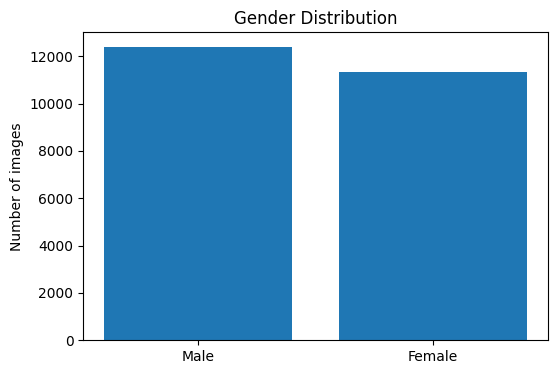

In [46]:
gender_counts = df['gender'].value_counts().sort_index()
gender_labels = ['Male', 'Female']

plt.figure(figsize=(6, 4))
plt.bar(gender_labels, gender_counts.values)
plt.title("Gender Distribution")
plt.ylabel("Number of images")
plt.show()

For the whole dataset we have a good balance between male and female

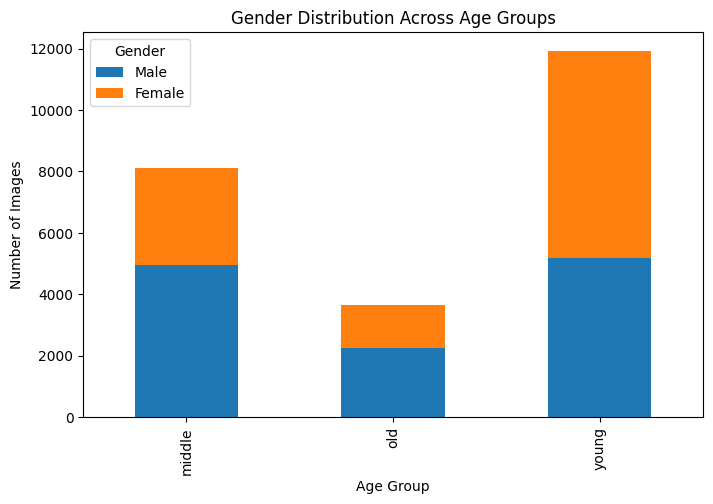

In [47]:

gender_age = df.groupby(["age_group", "gender"]).size().unstack()
gender_age.plot(kind="bar", stacked=True, figsize=(8,5))
gender_labels = ['Male', 'Female']



plt.title("Gender Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Images")
plt.legend(title="Gender", labels=gender_labels)

plt.show()

Old is heavily underrepresented, but with teqniques metioned above we can address this issue to some extent.

## 4. Sample images from the dataset

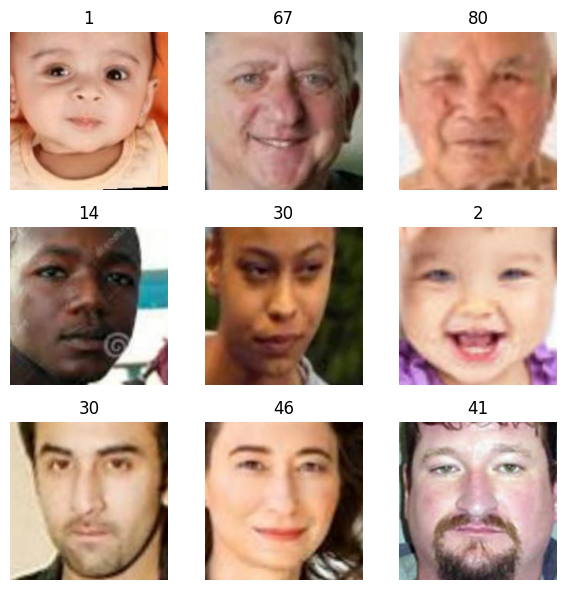

In [48]:
import random
from PIL import Image


images = list(data_path.glob("*.jpg"))
sample = random.sample(images, 9)

plt.figure(figsize=(6,6))

for i, img_path in enumerate(sample):
    img = Image.open(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(img_path.name.split("_")[0])
    plt.axis("off")

plt.tight_layout()
plt.show()